# Libraries

In [2]:
import pandas as pd 

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

import sklearn as sk

import statsmodels.api as sm 

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading  the pre-split datasets


churn_80_Original = pd.read_csv(r"C:\Users\DELL\Downloads\churn-bigml-80.csv")
churn_80_copied = churn_80_Original
churn_80_copied.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
churn_20_original = pd.read_csv(r"C:\Users\DELL\Downloads\churn-bigml-20.csv")
churn_20_copied = churn_20_original
churn_20_copied

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,WI,114,415,No,Yes,26,137.1,88,23.31,155.7,125,13.23,247.6,94,11.14,11.5,7,3.11,2,False
663,AL,106,408,No,Yes,29,83.6,131,14.21,203.9,131,17.33,229.5,73,10.33,8.1,3,2.19,1,False
664,VT,60,415,No,No,0,193.9,118,32.96,85.0,110,7.23,210.1,134,9.45,13.2,8,3.56,3,False
665,WV,159,415,No,No,0,169.8,114,28.87,197.7,105,16.80,193.7,82,8.72,11.6,4,3.13,1,False


In [5]:
print ("Train shape :", churn_80_copied.shape )
print ("Test shape:", churn_20_copied.shape )
print("Target distribution in Train: \n", churn_80_copied['Churn'].value_counts(normalize=True))

Train shape : (2666, 20)
Test shape: (667, 20)
Target distribution in Train: 
 Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64


In [6]:
# Preprocessing

x_churn_80 = churn_80_copied.drop('Churn',axis = 1)
y_churn_80 = churn_80_copied['Churn'].astype(int)
x_churn_20 = churn_20_copied.drop("Churn", axis=1)
y_churn_20 = churn_20_copied['Churn'].astype(int)

In [7]:
# Categorical & Numerical columns

cat_cols = ['State','International plan', 'Voice mail plan' ]
num_cols = [ col for col in x_churn_80.columns if col not in cat_cols]

In [8]:

# Preprocessor

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)])

In [9]:
# Defininig 3 models


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

In [10]:
# Training and Evaluating each model 



results = []

for name, model in models.items(): 
    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf', model)
    ])
    
    pipe.fit(x_churn_80, y_churn_80)
    y_pred = pipe.predict(x_churn_20)
    
    acc = accuracy_score(y_churn_20, y_pred)
    prec = precision_score(y_churn_20, y_pred)
    rec = recall_score(y_churn_20, y_pred)
    f1 = f1_score(y_churn_20, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4), 
        'Precision': round (prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })
    
    print(f"\n=== {name} ===")
    print(classification_report(y_churn_20,y_pred))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       572
           1       0.48      0.22      0.30        95

    accuracy                           0.85       667
   macro avg       0.68      0.59      0.61       667
weighted avg       0.82      0.85      0.83       667


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       572
           1       0.69      0.76      0.72        95

    accuracy                           0.92       667
   macro avg       0.82      0.85      0.84       667
weighted avg       0.92      0.92      0.92       667


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       572
           1       0.97      0.61      0.75        95

    accuracy                           0.94       667
   macro avg       0.95      0.80      0.86       667

In [11]:
# Summary Table

results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print("MODEL COMPARISON (on 20% Test set)")
print("=" * 60)
print(results_df.to_string(index=False))


MODEL COMPARISON (on 20% Test set)
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8546     0.4773  0.2211    0.3022
      Decision Tree    0.9160     0.6857  0.7579    0.7200
      Random Forest    0.9415     0.9667  0.6105    0.7484


In [12]:
# Hyperparameter Tuning – Random Forest


print("\nTuning Random Forest with GridSearchCV...")
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5]
}

grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring = 'f1', n_jobs= -1)
grid.fit(x_churn_80, y_churn_80)

print('Best parameters:', grid.best_params_)
print("Best CV F1-score:", round(grid.best_score_,4))

best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(x_churn_20)

print("\n=== TUNED RANDOM FOREST (Final) ===")
print(classification_report(y_churn_20, y_pred_tuned))


Tuning Random Forest with GridSearchCV...
Best parameters: {'clf__max_depth': 20, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Best CV F1-score: 0.7355

=== TUNED RANDOM FOREST (Final) ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       572
           1       0.97      0.63      0.76        95

    accuracy                           0.94       667
   macro avg       0.95      0.81      0.87       667
weighted avg       0.95      0.94      0.94       667



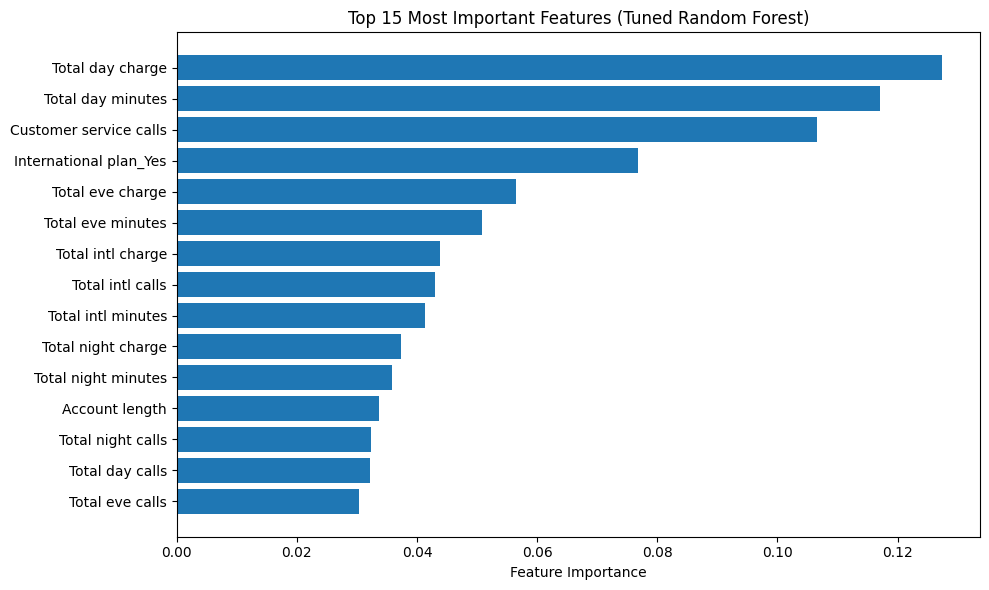

In [13]:
# Feature Importance Plot


rf_model = best_model.named_steps['clf']
feature_names = (best_model.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_cols).tolist() + num_cols)
importances = rf_model.feature_importances_
indices = importances.argsort() [-15:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features (Tuned Random Forest)')
plt.tight_layout()
plt.show()

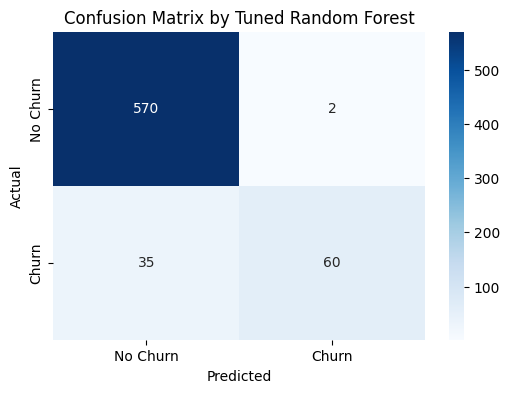

In [14]:
# Confusion Matrix


cm = confusion_matrix(y_churn_20, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix by Tuned Random Forest')
plt.show()